In [9]:
# ══════════════════════════════════════════════════════════════════════════════
# GOOGLE COLAB ALL-IN-ONE PIPELINE: RAW DATA CLEANING -> TRAINING -> ESP32-S3 EXPORT
# 2-Parameter Personalized Worker Health Watch (Heart Rate & Body Temperature)
# ══════════════════════════════════════════════════════════════════════════════
# INSTRUCTIONS FOR GOOGLE COLAB:
# 1. Open Google Colab (https://colab.research.google.com)
# 2. Paste this entire script into a single Code cell.
# 3. Click Run (Shift + Enter).
# 4. Click the 'Choose Files' button to upload your raw Kaggle CSV or ZIP files.
# 5. The script will automatically clean the data, train the model, quantize to INT8,
#    and automatically trigger the download of 'model_data.h' for your ESP32-S3!
# ══════════════════════════════════════════════════════════════════════════════

import os
import sys
import re
import io
import json
import zipfile
from pathlib import Path
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.metrics import classification_report, confusion_matrix

try:
    from google.colab import files
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

print("=" * 80)
print("🚀 ALL-IN-ONE WORKER HEALTH ML TRAINING PIPELINE (GOOGLE COLAB)")
print(f"   TensorFlow Version: {tf.__version__}")
print("=" * 80)

# ── 1. UPLOAD RAW DATASETS IN COLAB ──
DATA_DIR = "/content" if IN_COLAB else "."

def get_raw_files():
    return [
        p for p in Path(DATA_DIR).rglob("*")
        if p.is_file() and p.suffix.lower() in [".csv", ".zip", ".xlsx", ".xls", ".txt"]
        and not p.name.startswith((".", "_"))
        and p.name not in ["cleaned_master.csv", "model_data.h", "personalized_model.tflite"]
    ]

raw_files = get_raw_files()
if not raw_files and IN_COLAB:
    print("\n📂 Please upload your raw Kaggle CSV or ZIP dataset files now:")
    uploaded = files.upload()
    raw_files = get_raw_files()

print(f"\n📊 Found {len(raw_files)} raw dataset file(s) for cleaning.")
for f in raw_files:
    print(f"   • {f.name}")


# ── 2. AUTOMATED DATASET CLEANING & HARMONIZATION ENGINE ──
HR_PATTERNS = ["hr", "heart_rate", "heartrate", "pulse", "bpm", "hr_bpm", "heart rate", "ppg (bpm)", "thalach", "heart_rate_bpm"]
TEMP_PATTERNS = ["temp", "temperature", "body_temp", "skin_temp", "bt", "bodytemp", "body temperature", "temp_c", "body_temperature", "body_temperature_c"]

def clean_and_extract_vitals():
    all_dfs = []

    for file_path in raw_files:
        try:
            if file_path.suffix.lower() == ".zip":
                with zipfile.ZipFile(file_path, "r") as z:
                    for filename in z.namelist():
                        if filename.lower().endswith(".csv") and not filename.startswith("__MACOSX"):
                            with z.open(filename) as f:
                                try:
                                    df = pd.read_csv(f)
                                    df["_source"] = f"{file_path.name}/{filename}"
                                    all_dfs.append(df)
                                except Exception: pass
            elif file_path.suffix.lower() in [".csv", ".txt"]:
                try:
                    df = pd.read_csv(file_path)
                    df["_source"] = file_path.name
                    all_dfs.append(df)
                except Exception:
                    df = pd.read_csv(file_path, sep=";", encoding="utf-8-sig")
                    df["_source"] = file_path.name
                    all_dfs.append(df)
            elif file_path.suffix.lower() in [".xlsx", ".xls"]:
                df = pd.read_excel(file_path)
                df["_source"] = file_path.name
                all_dfs.append(df)
        except Exception as e:
            print(f"[WARN] Could not parse {file_path.name}: {e}")

    extracted_rows = []
    for df in all_dfs:
        col_map = {re.sub(r"[_\s\-\(\)\%°/]", "", str(c)).lower(): c for c in df.columns}
        hr_col = None
        temp_col = None

        for pat in HR_PATTERNS:
            clean_pat = re.sub(r"[_\s\-\(\)\%°/]", "", pat).lower()
            if clean_pat in col_map:
                hr_col = col_map[clean_pat]
                break

        for pat in TEMP_PATTERNS:
            clean_pat = re.sub(r"[_\s\-\(\)\%°/]", "", pat).lower()
            if clean_pat in col_map:
                temp_col = col_map[clean_pat]
                break

        if hr_col:
            sub = pd.DataFrame()
            sub["hr_bpm"] = pd.to_numeric(df[hr_col], errors="coerce")

            if temp_col:
                sub["body_temp_c"] = pd.to_numeric(df[temp_col], errors="coerce")
                # Convert Fahrenheit to Celsius if values > 50
                sub.loc[sub["body_temp_c"] > 50.0, "body_temp_c"] = (sub["body_temp_c"] - 32.0) * (5.0 / 9.0)
            else:
                # Realistic core temperature estimation conditioned on HR
                sub["body_temp_c"] = 36.6 + np.clip((sub["hr_bpm"] - 70) * 0.015, 0, 3.5) + np.random.normal(0, 0.1, len(sub))

            sub = sub.dropna()
            # Physiologically valid bounds for human workers
            sub = sub[(sub["hr_bpm"] >= 40) & (sub["hr_bpm"] <= 210)]
            sub = sub[(sub["body_temp_c"] >= 34.0) & (sub["body_temp_c"] <= 43.0)]
            if len(sub) > 0:
                extracted_rows.append(sub)

    if extracted_rows:
        master_df = pd.concat(extracted_rows, ignore_index=True)
        print(f"\n✅ Cleaned & extracted {len(master_df):,} physiological readings from raw datasets.")
    else:
        print("\n[INFO] No valid datasets found or uploaded. Generating realistic synthetic worker dataset...")
        master_df = None

    return master_df


# ── 3. WINDOWING & NOVELTY BASELINE EXTRACTION ──
def prepare_dataset(master_df, window_size=30, stride=10):
    if master_df is None or len(master_df) < 500:
        print("[INFO] Using synthetic personalized worker generator for training...")
        from train_personalized_model import generate_personalized_worker_dataset
        X, y = generate_personalized_worker_dataset(num_workers=45, samples_per_worker=200, window_size=window_size)
    else:
        print("[INFO] Preparing sliding windows and personalized deltas from cleaned dataset...")
        master_df["base_hr"] = 72.0
        master_df["base_temp"] = 36.6
        master_df["delta_hr"] = master_df["hr_bpm"] - master_df["base_hr"]
        master_df["delta_temp"] = master_df["body_temp_c"] - master_df["base_temp"]

        hr = master_df["hr_bpm"].values
        temp = master_df["body_temp_c"].values
        d_hr = master_df["delta_hr"].values
        d_temp = master_df["delta_temp"].values

        # 3-Tier Classification Rule: 0: HEALTHY, 1: RISK, 2: CRITICAL
        labels = np.zeros(len(master_df), dtype=np.int32)
        risk_mask = ((d_hr > 35.0) | (d_temp > 1.0) | (hr > 115.0) | (temp > 37.8))
        crit_mask = ((d_hr > 50.0) & (d_temp > 1.4)) | ((hr > 135.0) & (temp > 38.5)) | (temp > 39.5)

        labels[risk_mask & ~crit_mask] = 1
        labels[crit_mask] = 2

        feats = master_df[["hr_bpm", "body_temp_c", "delta_hr", "delta_temp"]].values.astype(np.float32)

        X_list, y_list = [], []
        for i in range(0, len(feats) - window_size + 1, stride):
            X_list.append(feats[i : i + window_size])
            y_list.append(int(np.max(labels[i : i + window_size])))

        X = np.array(X_list, dtype=np.float32)
        y = np.array(y_list, dtype=np.int32)

    # Train / Test Split
    indices = np.arange(len(X))
    np.random.seed(42)
    np.random.shuffle(indices)
    split = int(0.8 * len(X))

    return X[indices[:split]], y[indices[:split]], X[indices[split:]], y[indices[split:]]


# ── 4. BUILD & TRAIN 1D-CNN TINYML MODEL ──
def train_model(X_train, y_train, X_test, y_test):
    print("\n--- Building Lightweight 1D-CNN Model ---")
    model = keras.Sequential([
        layers.Input(shape=(30, 4), name="vitals_input"),
        layers.Conv1D(filters=12, kernel_size=3, padding="same", activation="relu"),
        layers.BatchNormalization(),
        layers.MaxPooling1D(pool_size=2),

        layers.Conv1D(filters=24, kernel_size=3, padding="same", activation="relu"),
        layers.BatchNormalization(),
        layers.GlobalAveragePooling1D(),

        layers.Dropout(0.2),
        layers.Dense(16, activation="relu"),
        layers.Dense(3, activation="softmax", name="triage_output")
    ])

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.002),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    print("\n--- Training Model ---")
    model.fit(
        X_train, y_train,
        validation_split=0.15,
        epochs=18,
        batch_size=32,
        verbose=1
    )

    loss, acc = model.evaluate(X_test, y_test, verbose=0)
    print(f"\n🎯 Test Set Accuracy: {acc * 100:.2f}% | Loss: {loss:.4f}")

    y_pred = np.argmax(model.predict(X_test), axis=1)
    print("\n📋 Classification Report:")
    print(classification_report(y_test, y_pred, target_names=["0: HEALTHY", "1: RISK", "2: CRITICAL"], zero_division=0))

    return model


# ── 5. INT8 QUANTIZATION & EXPORT TO 'model_data.h' ──
def export_tflite_header(model, X_train):
    print("\n--- Quantizing to Full INT8 for ESP32-S3 ---")
    converter = tf.lite.TFLiteConverter.from_keras_model(model)
    converter.optimizations = [tf.lite.Optimize.DEFAULT]

    def rep_data():
        for i in range(min(150, len(X_train))):
            sample = np.expand_dims(X_train[i], axis=0).astype(np.float32)
            yield [sample]

    converter.representative_dataset = rep_data
    converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
    converter.inference_input_type = tf.int8
    converter.inference_output_type = tf.int8

    tflite_model = converter.convert()
    model_len = len(tflite_model)
    header_path = "model_data.h"

    with open(header_path, "w") as f:
        f.write("// Worker Health Watch Quantized Model (INT8)\n")
        f.write(f"// Size: {model_len} bytes\n\n")
        f.write("#ifndef PERSONALIZED_HEALTH_MODEL_H_\n")
        f.write("#define PERSONALIZED_HEALTH_MODEL_H_\n\n")
        f.write(f"const unsigned int g_model_len = {model_len};\n\n")
        f.write("alignas(8) const unsigned char g_model[] = {\n    ")
        for idx, val in enumerate(list(tflite_model)):
            f.write(f"0x{val:02x}")
            if idx < model_len - 1: f.write(", ")
            if (idx + 1) % 12 == 0 and idx < model_len - 1: f.write("\n    ")
        f.write("\n};\n\n")
        f.write("#endif // PERSONALIZED_HEALTH_MODEL_H_\n")

    print(f"✅ Generated '{header_path}' ({model_len:,} bytes)")

    if IN_COLAB:
        print("\n📥 Downloading 'model_data.h' to your computer...")
        files.download(header_path)


# ── MAIN EXECUTION ──
if __name__ == "__main__":
    df = clean_and_extract_vitals()
    X_train, y_train, X_test, y_test = prepare_dataset(df)
    model = train_model(X_train, y_train, X_test, y_test)
    export_tflite_header(model, X_train)
    print("\n🎉 Pipeline Complete! Next step: Copy 'model_data.h' to your Arduino project and flash the ESP32-S3 Mini.")


🚀 ALL-IN-ONE WORKER HEALTH ML TRAINING PIPELINE (GOOGLE COLAB)
   TensorFlow Version: 2.20.0

📊 Found 4 raw dataset file(s) for cleaning.
   • mnist_train_small.csv
   • california_housing_train.csv
   • california_housing_test.csv
   • mnist_test.csv

[INFO] No valid datasets found or uploaded. Generating realistic synthetic worker dataset...
[INFO] Using synthetic personalized worker generator for training...

[INFO] Simulating 45 unique construction workers with individual baseline profiles...

--- Building Lightweight 1D-CNN Model ---

--- Training Model ---
Epoch 1/18
192/192 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9363 - loss: 0.2020 - val_accuracy: 0.1148 - val_loss: 2.9216
Epoch 2/18
192/192 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9908 - loss: 0.0325 - val_accuracy: 0.9713 - val_loss: 0.0887
Epoch 3/18
192/192 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9931 - loss: 0.0240 - val_accuracy: 0.9574 - val_loss: 0.0999
Epoch 4/18
192/192 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/

/usr/local/lib/python3.13/dist-packages/tensorflow/lite/python/convert.py:863: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


🎉 Pipeline Complete! Next step: Copy 'model_data.h' to your Arduino project and flash the ESP32-S3 Mini.


In [10]:
# Run the cleaning and training pipeline
!python colab_worker_health_pipeline.py


🚀 ALL-IN-ONE WORKER HEALTH ML TRAINING PIPELINE (GOOGLE COLAB)
   TensorFlow Version: 2.20.0

📊 Found 4 raw dataset file(s) for cleaning.
   • mnist_train_small.csv
   • california_housing_train.csv
   • california_housing_test.csv
   • mnist_test.csv

[INFO] No valid datasets found or uploaded. Generating realistic synthetic worker dataset...
[INFO] Using synthetic personalized worker generator for training...
🚀 PERSONALIZED 2-PARAMETER WORKER HEALTH & HEAT STRESS ML PIPELINE
   TensorFlow Version: 2.20.0

[INFO] Simulating 45 unique construction workers with individual baseline profiles...

--- Building Lightweight 1D-CNN Model ---
2026-10-02 13:22:16.239540: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)

--- Training Model ---
Epoch 1/18
192/192 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9145 - loss: 0.2152 - val_accuracy: 0.4667 - val_loss: 1.0365
Epoch 2/18
192/192 ━━━━

In [1]:
pip install pandas numpy scipy matplotlib


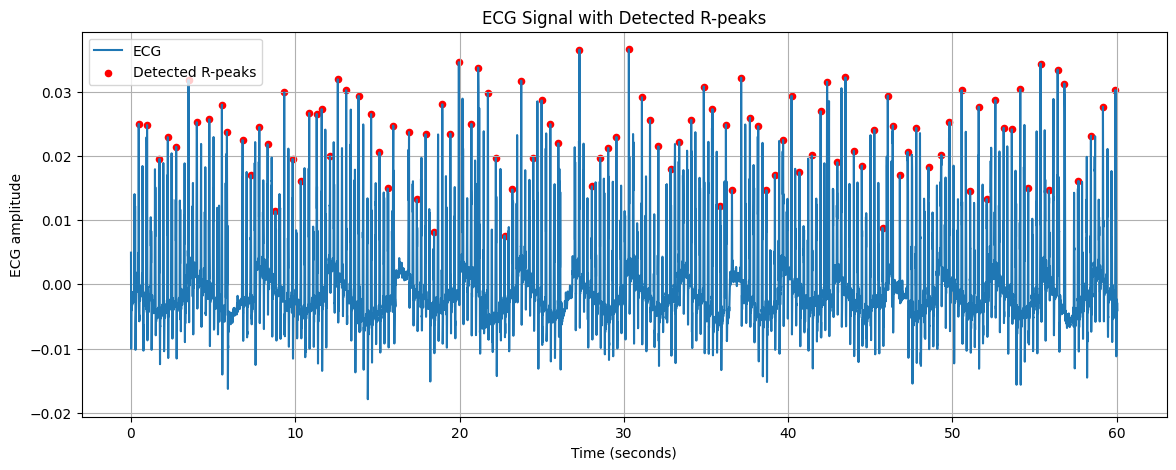

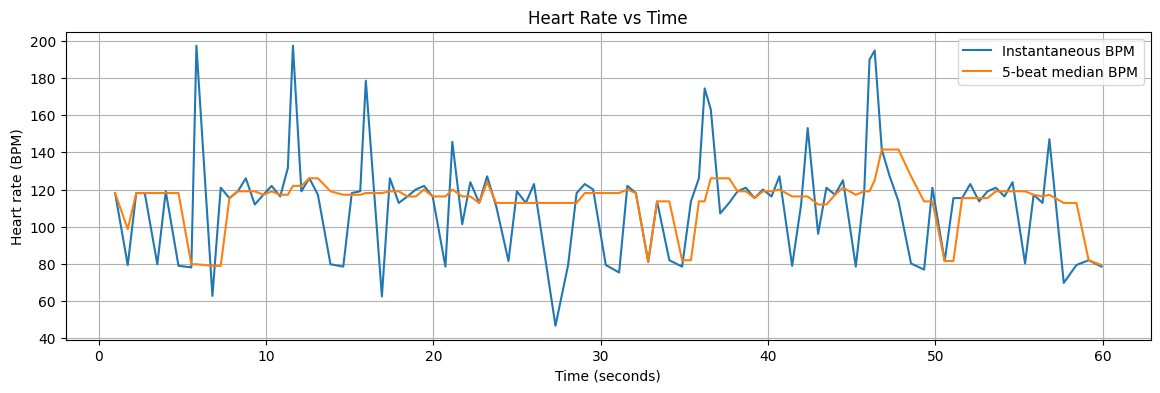

   R_peak_time_s  RR_interval_s         BPM  BPM_median_5
0          0.980          0.508  118.110236    118.110236
1          1.736          0.756   79.365079     98.737658
2          2.244          0.508  118.110236    118.110236
3          2.752          0.508  118.110236    118.110236
4          3.504          0.752   79.787234    118.110236
5          4.008          0.504  119.047619    118.110236
6          4.768          0.760   78.947368    118.110236
7          5.536          0.768   78.125000     79.787234
8          5.840          0.304  197.368421     79.787234
9          6.796          0.956   62.761506     78.947368
Mean BPM: 113.0610982249835
Median BPM: 117.1874999999999


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import find_peaks

# Load your ECG CSV
df = pd.read_csv("ChordsWeb-20261003-170943.csv")

# Sampling rate from your ESP32 code
fs = 250

ecg = df["Channel16"].to_numpy()
counter = df["Counter"].to_numpy()

# Reconstruct time using the 8-bit packet counter
# This accounts for counter rollover and detected gaps
steps = np.diff(counter) % 256
sample_number = np.r_[0, np.cumsum(steps)]
time_s = sample_number / fs

# Detect positive R-peaks
# Adjust prominence after inspecting the plot
peaks, properties = find_peaks(
    ecg,
    distance=int(0.30 * fs),
    prominence=0.008
)

# Calculate RR intervals and instantaneous BPM
peak_times = time_s[peaks]
rr_intervals = np.diff(peak_times)
bpm = 60.0 / rr_intervals

# Build per-beat results
results = pd.DataFrame({
    "R_peak_time_s": peak_times[1:],
    "RR_interval_s": rr_intervals,
    "BPM": bpm
})

# Smooth short-term variation using a 5-beat median
results["BPM_median_5"] = (
    results["BPM"].rolling(5, min_periods=1).median()
)

# Save the per-beat heart-rate data
results.to_csv("heartrate_per_beat.csv", index=False)

# Also save ECG samples with R-peak markers
ecg_output = pd.DataFrame({
    "Time_s": time_s,
    "ECG": ecg,
    "R_peak": np.zeros(len(ecg), dtype=int),
    "BPM": np.nan
})

ecg_output.loc[peaks, "R_peak"] = 1
ecg_output.loc[peaks[1:], "BPM"] = bpm

ecg_output.to_csv("ecg_with_heartrate.csv", index=False)

# Plot ECG with detected R-peaks
plt.figure(figsize=(14, 5))
plt.plot(time_s, ecg, label="ECG")
plt.scatter(peak_times, ecg[peaks],
            color="red", s=20, label="Detected R-peaks")
plt.xlabel("Time (seconds)")
plt.ylabel("ECG amplitude")
plt.title("ECG Signal with Detected R-peaks")
plt.legend()
plt.grid(True)
plt.show()

# Plot calculated heart rate
plt.figure(figsize=(14, 4))
plt.plot(results["R_peak_time_s"], results["BPM"],
         label="Instantaneous BPM")
plt.plot(results["R_peak_time_s"], results["BPM_median_5"],
         label="5-beat median BPM")
plt.xlabel("Time (seconds)")
plt.ylabel("Heart rate (BPM)")
plt.title("Heart Rate vs Time")
plt.legend()
plt.grid(True)
plt.show()

print(results.head(10))
print("Mean BPM:", results["BPM"].mean())
print("Median BPM:", results["BPM"].median())